# Sentiment Augmented Ensemble Deep Reinforcemnet Learning: Algorithmic Trading on OMX Stockholm 30 Constituents

This notebook implements the experimental pipeline described in the thesis:  
**"Sentiment-Augmented Ensemble Deep Reinforcement Learning for Algorithmic Trading on OMXS30 Constituents"**  
Author: Beatrice S.A. Mossberg (2025)


## Part 1. Problem Definition

The problem of automated equity trading is formulated as a **Markov Decision Process (MDP)**, where the agent interacts with a dynamic financial environment to optimize portfolio returns.

The components of the RL environment are defined as follows:

- **State (`s`)**: A multidimensional vector comprising:
  - Historical technical indicators (e.g., MACD, RSI)
  - Engineered sentiment features derived from translated financial news
  - Current portfolio holdings and cash balance

- **Action (`a`)**: A discrete value from the set \({-k, ..., -1, 0, 1, ..., k}\), where each integer represents the number of shares to buy (>0), hold (0), or sell (<0).  
  Example: \( a = -10 \) implies "sell 10 shares"; \( a = 5 \) implies "buy 5 shares".

- **Reward (`r(s,a,s')`)**: The change in portfolio value:
  \[
  r = V(s') - V(s)
  \]
  where \(V\) is the net portfolio value at the current or next time step.

- **Environment**: The agent interacts with a simulated market of OMXS30 index constituents, using daily OHLCV data obtained via Yahoo Finance.

The objective is to train an agent using DRL to maximize long-term risk-adjusted returns while adapting to changing market regimes using both **technical and sentiment signals**.


## Part 2. Setup and Dependencies

We install and import all required packages, primarily through the `FinRL` library, along with additional modules for sentiment analysis and feature engineering.

In [ ]:
!pip uninstall numpy -y
!pip uninstall pandas -y
!pip cache purge
!pip install numpy==1.26.4
!pip install pandas==1.5.3

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Files removed: 0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 60.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
arviz 0.21.0 requires pandas>=1.5.0, which is not installed.
bigframes 1.42.0 requires pandas>=1.5.3, which is not installed.
shap 0.47.1 requires pandas, which is not installed.
datascience 0.17.6 requires pandas, which is not installed.
db-dtypes 1.4.2 requires pandas>=0.24.2, which is not installed.
tensorflow-decision-forests 1.11.0 requires pandas, which is not installed.
mlxtend 0.23.4 requires pandas>=0.24.2, which is not i

In [4]:
# install finrl library
!pip install wrds
!pip install swig
!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
!pip install git+https://github.com/AI4Finance-LLC/FinRL-Library.git --use-deprecated=legacy-resolver
!pip install pandas_market_calendars

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 24.6 MB/s eta 0:00:00
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package swig4.0.
(Reading database ... 126101 files and directories currently installed.)
Preparing to unpack .../swig4.0_4.0.2-1ubuntu1_amd64.deb ...
Unpacking swig4.0 (4.0.2-1ubuntu1) ...
Selecting previously unselected package swig.
Preparing to unpack .../swig_4.0.2-1ubuntu1_all.deb ...
Unpacking swig (4.0.2-1ubuntu1) ...
Setting up swig4.0 (4.0.2-1ubuntu1) ...
Setting up swig (4.0.2-1ubuntu1) ...
Processing triggers for man-db (2.10.2-1) ...
  Cloning https://github.com/AI4Finance-LLC/FinRL-Library.git to /tmp/pip-req-build-2xb24o3z
  Running command git clone --filter=blob:none --quiet https://github.com/AI4Fina

### 2.2. Check if the additional packages needed are present, if not install them.
* Yahoo Finance API
* pandas
* numpy
* matplotlib
* stockstats
* OpenAI gym
* stable-baselines
* tensorflow
* pyfolio

### 2.3. Import Packages

In [5]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')
import datetime

%matplotlib inline
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent,DRLEnsembleAgent
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline

from pprint import pprint

import sys
sys.path.append("../FinRL-Library")

import itertools


/usr/local/lib/python3.11/dist-packages/websockets/legacy/__init__.py:6: DeprecationWarning: websockets.legacy is deprecated; see https://websockets.readthedocs.io/en/stable/howto/upgrade.html for upgrade instructions
  warnings.warn(  # deprecated in 14.0 - 2024-11-09
/usr/local/lib/python3.11/dist-packages/pandas_datareader/compat/__init__.py:11: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  PANDAS_VERSION = LooseVersion(pd.__version__)


### 2.4. Create Folders

In [6]:
import os
from finrl.main import check_and_make_directories
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
    TRAIN_START_DATE,
    TRAIN_END_DATE,
    TEST_START_DATE,
    TEST_END_DATE,
    TRADE_START_DATE,
    TRADE_END_DATE,
)

check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])

## Part 3. Data Aquisition, EDA and Preprocessing



### 3.1. Financial News Data

In [ ]:
file_ticker_map = {
    'ABB.ST': ['ABB.txt'], 'ALFA.ST': ['AlfaLaval.txt'], 'ASSA-B.ST': ['AssaAbloy.txt'],
    'AZN.ST': ['AstraZeneca.txt'], 'ATCO-A.ST': ['AtlasCopco.txt'], 'ATCO-B.ST': ['AtlasCopco.txt'],
    'BOL.ST': ['Boliden.txt'], 'ELUX-B.ST': ['Electrolux.txt'], 'ERIC-B.ST': ['Ericsson.txt'],
    'ESSITY-B.ST': ['Essity.txt'], 'EVO.ST': ['Evolution.txt'], 'GETI-B.ST': ['Getinge.txt'],
    'HM-B.ST': ['H&M.txt', 'H&M2.txt'], 'SHB-A.ST': ['Handelsbanken.txt'], 'HEXA-B.ST': ['Hexagon.txt'],
    'INVE-B.ST': ['Investor.txt'], 'KINV-B.ST': ['Kinnevik.txt'], 'NIBE-B.ST': ['Nibe.txt'],
    'NDA-SE.ST': ['Nordea.txt'], 'SBB-B.ST': ['SBB.txt'], 'SCA-B.ST': ['SCA.txt'],
    'SEB-A.ST': ['SEB.txt'], 'SKF-B.ST': ['SKF.txt'], 'SAAB-B.ST': ['Saab.txt'],
    'SAND.ST': ['Sandvik.txt'], 'SINCH.ST': ['Sinch.txt'], 'SWED-A.ST': ['Swedbank.txt'],
    'TEL2-B.ST': ['Tele2.txt'], 'TELIA.ST': ['Telia.txt'], 'VOLV-B.ST': ['Volvo.txt', 'Volvo1.txt', 'Volvo2.txt'],
}

entries = []
pattern = r'>\s*(.+?),\s*Dagens industri,\s*(\d{4}-\d{2}-\d{2})\n(.*?)(?=\n\s*>|\Z)'

for ticker, files in file_ticker_map.items():
    for file_path in files:
        if not os.path.exists(file_path):
            continue
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
            matches = re.findall(pattern, text, flags=re.DOTALL)
            for headline, date, preamble in matches:
                headline = headline.replace('■', '').strip() # Remove '■' symbol and extra spaces
                preamble = preamble.replace('■', '').strip()
                entries.append({'date': date.strip(), 'headline': headline, 'preamble': preamble, 'ticker': ticker
                })

if entries:
    df = pd.DataFrame(entries)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df[['date', 'headline', 'preamble', 'ticker']]
    df.to_csv("di_articles.csv", index=False, encoding='utf-8')
    display(df.head())
else:
    print("No entries extracted.")

,date,headline,preample,ticker
0,2015-02-06,Utdelningen räddar ABB,ABB:s fjärde kvartal var till synes svagare än...,ABB.ST
1,2015-03-17,ABB har fått i uppdrag att,bygga elstationer som ska förse oljefältet Joh...,ABB.ST
2,2015-03-20,ABB-order hotad,Genom att stoppa affärsvisum till Saudiarabien...,ABB.ST
3,2015-04-10,ABB tar hem kinesisk kraftorder,ABB i Ludvika har fått en order på ett kraftnä...,ABB.ST
4,2015-04-17,Experten: ABB borde styckas,"Mathias Leijon, chef för aktieförvaltning på N...",ABB.ST


In [ ]:
# Basic info
print("=== Shape ===")
print(df.shape)
print("\n=== Info ===")
display(df.info())
# Check for missing values
print("=== Missing Values ===")
display(df.isnull().sum())
# Duplicates
print("\n=== Duplicate Rows ===")
print('Dropped duplicate: ')
display(df[df.duplicated()])
df.drop_duplicates(inplace=True)
# Descriptive statistics
print("=== Descriptive Stats ===")
display(df.describe(include='all'))

=== Shape ===
(9220, 9)

=== Info ===
<class 'pandas.core.frame.DataFrame'>
Index: 9220 entries, 0 to 9220
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 9220 non-null   datetime64[ns]
 1   headline             9220 non-null   object        
 2   preample             9220 non-null   object        
 3   ticker               9220 non-null   object        
 4   headline_length      9220 non-null   int64         
 5   preample_length      9220 non-null   int64         
 6   combined_text        9220 non-null   object        
 7   translated_combined  9220 non-null   object        
 8   translated_headline  9220 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 720.3+ KB


None

=== Missing Values ===


,0
date,0
headline,0
preample,0
ticker,0
headline_length,0
preample_length,0
combined_text,0
translated_combined,0
translated_headline,0



=== Duplicate Rows ===
Dropped duplicate: 


,date,headline,preample,ticker,headline_length,preample_length,combined_text,translated_combined,translated_headline


=== Descriptive Stats ===


,date,headline,preample,ticker,headline_length,preample_length,combined_text,translated_combined,translated_headline
count,9220,9220,9220,9220,9220.000000,9220.000000,9220,9220,9220
unique,NaN,8527,7118,30,NaN,NaN,8602,8602,8474
top,NaN,"Essity, SEB, Alfa Laval, Evolution Gaming, SSA...",,VOLV-B.ST,NaN,NaN,"Essity, SEB, Alfa Laval, Evolution Gaming, SSA...","Essity, SEB, Alfa Laval, Evolution Gaming, SSA...","Essity, SEB, Alfa Laval, Evolution Gaming, SSA..."
freq,NaN,6,1623,1263,NaN,NaN,6,6,6
mean,2020-04-03 01:44:47.895878400,NaN,NaN,NaN,33.602603,157.769523,NaN,NaN,NaN
min,2015-01-05 00:00:00,NaN,NaN,NaN,4.000000,0.000000,NaN,NaN,NaN
25%,2018-01-10 18:00:00,NaN,NaN,NaN,27.000000,111.000000,NaN,NaN,NaN
50%,2020-06-17 00:00:00,NaN,NaN,NaN,32.000000,170.000000,NaN,NaN,NaN
75%,2022-07-15 06:00:00,NaN,NaN,NaN,38.000000,224.000000,NaN,NaN,NaN
max,2024-12-28 00:00:00,NaN,NaN,NaN,200.000000,402.000000,NaN,NaN,NaN


In [8]:
import seaborn as sns

# Set global style
plt.style.use('default')

# Print basic date info
print("=== Date Range ===")
print(f"Start: {df['date'].min().date()}")
print(f"End: {df['date'].max().date()}")
print(f"Duration: {(df['date'].max() - df['date'].min()).days} days")

# Set up the figure with 4 simple plots
plt.figure(figsize=(15, 10))

# 1. Articles per Year (simple bar plot)
plt.subplot(2, 2, 1)
yearly = df['date'].dt.year.value_counts().sort_index()
sns.barplot(x=yearly.index, y=yearly.values, color='#1a1a1a')
plt.title('Articles per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)

# 2. Articles by Month (bar plot)
plt.subplot(2, 2, 2)
monthly = df['date'].dt.month.value_counts().sort_index()
sns.barplot(x=monthly.index, y=monthly.values, color='#1a1a1a')
plt.title('Articles by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(axis='y', alpha=0.3)

# 3. Top Tickers Over Time (line plot)
plt.subplot(2, 1, 2)
top_tickers = df['ticker'].value_counts().head(10).index
for ticker in top_tickers:
    temp = df[df['ticker'] == ticker].resample('M', on='date').count()
    plt.plot(temp.index, temp['headline'], label=ticker)
plt.title('Top 10 Tickers Yearly Count')
plt.xlabel('Year')
plt.ylabel('Articles')
plt.legend(loc='upper left')
plt.grid(alpha=0.3)

# Adjust layout
plt.tight_layout()
plt.show()

# 4. Ticker Distribution (separate figure for clarity)
plt.figure(figsize=(12, 5))
ticker_counts = df['ticker'].value_counts()
sns.barplot(x=ticker_counts.index, y=ticker_counts.values, color='#1a1a1a')
plt.title('Articles per Ticker')
plt.xlabel('Ticker')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

=== Date Range ===
Start: 2015-01-05
End: 2024-12-28
Duration: 3645 days


In [9]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

swedish_stopwords = set(stopwords.words('swedish'))
#add custom stopwords
custom_stopwords = [
    'volvo', 'car', 'cars', 'h&m', 'h', 'm', '&', 'atlas', 'copco', 'investor', 'sandvik', 'ericsson',
    'assa', 'abloy', 'astra', 'zeneca', 'saab', 'astrazeneca', 'seb', 'swedbank', 'nordea', 'svenska', 'handelsbanken',
    'telia', 'skanska', 'electrolux', 'boliden', 'skf', 'hexagon', 'abb',
    'sca', 'alfa', 'laval', 'kinnevik', 'essity', 'sinch', 'epiroc', 'getinge',
    'autoliv', 'evolution', 'nibe', 'industrier', 'embracer', 'fastighets', 'ab', 'nan',
    'sbb', 'bolaget', 'säger'
]
all_stopwords = swedish_stopwords.union(custom_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
# Combine headlines and preambles into one text
all_text = ' '.join(df['headline'] + ' ' + df['preample'])

from wordcloud import WordCloud
from collections import Counter

sns.set_style("whitegrid")

# Custom color function
def grey_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "#1a1a1a"

# Generate the word cloud with specified color
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=all_stopwords,
    color_func=grey_color_func
).generate(all_text)

# Most common words (excluding stopwords)
words = [word.lower() for word in all_text.split() if word.isalpha()]
words = [word for word in words if word not in all_stopwords]
word_counts = Counter(words).most_common(20)

# Add text length columns
df['headline_length'] = df['headline'].apply(len)
df['preample_length'] = df['preample'].apply(len)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Word Cloud plot
axes[0, 0].imshow(wordcloud, interpolation='bilinear')
axes[0, 0].axis('off')
axes[0, 0].set_title('Word Cloud of Headlines and Text')

# Most common words bar chart
axes[0, 1].barh([w[0] for w in word_counts], [w[1] for w in word_counts], color='#1a1a1a')
axes[0, 1].set_title('Top 20 Most Frequent Words (Excluding Stopwords)')
axes[0, 1].set_xlabel('Frequency')
axes[0, 1].set_ylabel('Word')
axes[0, 1].invert_yaxis()

# Headline length distribution
sns.histplot(df['headline_length'], bins=30, ax=axes[1, 0], color='black')
axes[1, 0].set_title('Headline Length Distribution')
axes[1, 0].set_xlabel('Character Count')

# Preample length distribution
sns.histplot(df['preample_length'], bins=30, ax=axes[1, 1], color='black')
axes[1, 1].set_title('Preamble Length Distribution')
axes[1, 1].set_xlabel('Character Count')

# Adjust layout for a cleaner view
plt.tight_layout()
plt.show()

#Print Preample length = 0 count
print(f"Number of rows with preample_length = 0: {len(df[df['preample_length'] == 0])}")

Number of rows with preample_length = 0: 0


1623 preample rows are empty string. this is remedied since we combine the title and preample for the translation and sentiment analysis.

### 3.2. Translating Content
Dagens Industri headlines and article leads are initially available in Swedish. To perform downstream sentiment analysis using FinBERT (trained on English corpora), we translate the text to English using the `GoogleTranslator` API via the `deep_translator` package.

To reduce latency and API failure, we implement:
- **Batch translation** with a retry mechanism.
- **Long-text splitting** for texts exceeding token limits (max ~4500 characters).
- **Caching** via `.csv` exports to avoid re-translation.

This preprocessing yields a `translated_combined` column used for sentiment inference.

In [ ]:
!pip install deep_translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
import torch
from tqdm import tqdm
import time
from deep_translator import GoogleTranslator, exceptions

df['combined_text'] = df['headline'] + '. ' + df['preamble'].fillna('') # Combine headline and preample

def batch_translate(texts, src="sv", tgt="en", batch_size=16, max_retries=3, retry_delay=10):
    """Translate texts in batches with retries for failed batches."""
    translator = GoogleTranslator(source=src, target=tgt)
    translated_texts = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Translating content"):
        batch = texts[i:i+batch_size]
        success = False
        retries = 0

        while not success and retries < max_retries:
            try:
                # Split very long texts (>5000 chars) to avoid API limits
                processed_batch = []
                for text in batch:
                    if len(text) > 5000:
                        parts = [text[i:i+4500] for i in range(0, len(text), 4500)]
                        translated_parts = translator.translate_batch(parts)
                        processed_batch.append(' '.join(translated_parts))
                    else:
                        processed_batch.append(text)
                # Translate the processed batch
                if len(batch) == len(processed_batch):  # No splitting needed
                    translated_texts.extend(translator.translate_batch(batch))
                else:
                    translated_texts.extend(processed_batch)
                success = True

            except exceptions.TranslationNotFound:
                retries += 1
                print(f"Translation failed for batch starting at index {i}, attempt {retries}/{max_retries}")
                if retries < max_retries:
                    time.sleep(retry_delay)
                else:
                    print(f"Skipping batch at index {i} after {max_retries} failed attempts.")
                    translated_texts.extend([""] * len(batch))

    return translated_texts

df["translated_combined"] = batch_translate(df["combined_text"].tolist(), batch_size=32)
df.to_csv("di_combined_translated.csv", index=False)
df.head()

Translating content:   5%|▍         | 27/577 [07:58<2:44:13, 17.92s/it]

Translation failed for batch starting at index 432, attempt 1/3


Translating content:  73%|███████▎  | 419/577 [1:57:10<43:01, 16.34s/it]

Translation failed for batch starting at index 6704, attempt 1/3


Translating content:  25%|██▍       | 71/289 [38:18<2:02:15, 33.65s/it]

Translation failed for batch starting at index 2272, attempt 1/3


Translating content: 100%|██████████| 289/289 [2:36:35<00:00, 32.51s/it]


,date,headline,preample,ticker,headline_length,preample_length,combined_text,translated_combined,translated_headline
0,2015-02-06,Utdelningen räddar ABB,ABB:s fjärde kvartal var till synes svagare än...,ABB.ST,22,209,Utdelningen räddar ABB. ABB:s fjärde kvartal v...,The dividend saves ABB. ABB's fourth quarter w...,The dividend saves ABB
1,2015-03-17,ABB har fått i uppdrag att,bygga elstationer som ska förse oljefältet Joh...,ABB.ST,26,104,ABB har fått i uppdrag att. bygga elstationer ...,ABB has been commissioned to. build electricit...,ABB has been commissioned to
2,2015-03-20,ABB-order hotad,Genom att stoppa affärsvisum till Saudiarabien...,ABB.ST,15,227,ABB-order hotad. Genom att stoppa affärsvisum ...,ABB order threatened. By stopping business vis...,ABB order threatened
3,2015-04-10,ABB tar hem kinesisk kraftorder,ABB i Ludvika har fått en order på ett kraftnä...,ABB.ST,31,223,ABB tar hem kinesisk kraftorder. ABB i Ludvika...,ABB takes home Chinese power order. ABB in Lud...,ABB takes home Chinese power order
4,2015-04-17,Experten: ABB borde styckas,"Mathias Leijon, chef för aktieförvaltning på N...",ABB.ST,27,101,"Experten: ABB borde styckas. Mathias Leijon, c...","The expert: ABB should be cut. Mathias Leijon,...",The expert: ABB should be cut


### 3.3. Sentiment Analysis
We utilize **FinBERT**, a domain-specific BERT model fine-tuned on financial text, to extract sentiment scores from translated headlines. For each translated article, we compute:

- **Sentiment Label**: {positive, neutral, negative}
- **Softmax Probabilities**: Probability distribution over labels
- **Composite Score**: A continuous polarity score:  
  \[
  \text{sentiment\_score} = P_{\text{positive}} - P_{\text{negative}}
  \]

These scores are then aggregated per day and per ticker to produce time-aligned sentiment features.


In [ ]:
!pip install transformers

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import pandas as pd
import scipy.special
from tqdm import tqdm

# Load FinBERT model and tokenizer
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Load translated dataset
df_sentiment = pd.read_csv("di_combined_translated.csv")
X = df_sentiment["translated_combined"].tolist()  # Using combined translation

# Predict sentiment
preds = []
preds_proba = []
sentiment_scores = []  # Store all scores for analysis
tokenizer_kwargs = {"padding": True, "truncation": True, "max_length": 512, "return_tensors": "pt"}

# Iterate through translated content
for x in tqdm(X, desc="Analyzing sentiment", leave=True, dynamic_ncols=True, position=0):
    if not isinstance(x, str) or not x.strip():# Handle empty/missing text
        preds.append("neutral")
        preds_proba.append(0.33)  # Neutral probability
        sentiment_scores.append({"positive": 0.33, "negative": 0.33, "neutral": 0.33})
        continue

    try:
        with torch.no_grad():
            inputs = tokenizer(x, **tokenizer_kwargs)
            logits = model(**inputs).logits
            scores = {k: float(v) for k, v in zip(model.config.id2label.values(), scipy.special.softmax(logits.numpy().squeeze())) }

            sentiment = max(scores, key=scores.get)
            probability = scores[sentiment]

            preds.append(sentiment)
            preds_proba.append(probability)
            sentiment_scores.append(scores)

    except Exception as e:
        print(f"Error processing text: {str(e)[:100]}...")
        preds.append("neutral")
        preds_proba.append(0.33)
        sentiment_scores.append({"positive": 0.33, "negative": 0.33, "neutral": 0.33})

df_sentiment["finbert_sentiment"] = preds
df_sentiment["finbert_confidence"] = preds_proba

# Add individual sentiment scores
df_sentiment = pd.concat([df_sentiment,pd.DataFrame(sentiment_scores).add_prefix("score_")], axis=1)

df_sentiment.to_csv("di_combined_sentiment.csv", index=False)

df_sentiment.head()

Analyzing sentiment: 100%|██████████| 9220/9220 [31:36<00:00,  4.86it/s]


Sentiment analysis complete. Results saved.


,date,headline,preample,ticker,headline_length,preample_length,combined_text,translated_combined,translated_headline,finbert_sentiment,finbert_confidence,score_positive,score_negative,score_neutral
0,2015-02-06,Utdelningen räddar ABB,ABB:s fjärde kvartal var till synes svagare än...,ABB.ST,22,209,Utdelningen räddar ABB. ABB:s fjärde kvartal v...,The dividend saves ABB. ABB's fourth quarter w...,The dividend saves ABB,positive,0.784540,0.784540,0.181511,0.033949
1,2015-03-17,ABB har fått i uppdrag att,bygga elstationer som ska förse oljefältet Joh...,ABB.ST,26,104,ABB har fått i uppdrag att. bygga elstationer ...,ABB has been commissioned to. build electricit...,ABB has been commissioned to,neutral,0.614714,0.377449,0.007837,0.614714
2,2015-03-20,ABB-order hotad,Genom att stoppa affärsvisum till Saudiarabien...,ABB.ST,15,227,ABB-order hotad. Genom att stoppa affärsvisum ...,ABB order threatened. By stopping business vis...,ABB order threatened,negative,0.933673,0.010949,0.933673,0.055378
3,2015-04-10,ABB tar hem kinesisk kraftorder,ABB i Ludvika har fått en order på ett kraftnä...,ABB.ST,31,223,ABB tar hem kinesisk kraftorder. ABB i Ludvika...,ABB takes home Chinese power order. ABB in Lud...,ABB takes home Chinese power order,positive,0.623690,0.623690,0.009450,0.366860
4,2015-04-17,Experten: ABB borde styckas,"Mathias Leijon, chef för aktieförvaltning på N...",ABB.ST,27,101,"Experten: ABB borde styckas. Mathias Leijon, c...","The expert: ABB should be cut. Mathias Leijon,...",The expert: ABB should be cut,negative,0.492881,0.143119,0.492881,0.364000


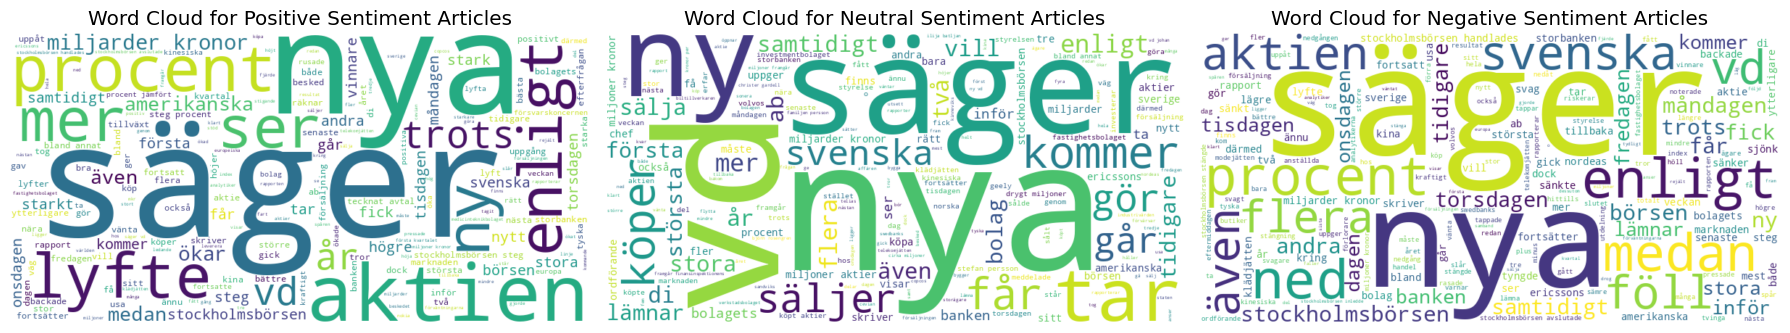

In [ ]:
# Unique sentiment classes
sentiments = df_sentiment['finbert_sentiment'].unique()

# Set up figure
plt.figure(figsize=(18, 6))

# Loop through each sentiment class
for i, sentiment in enumerate(sentiments):
    plt.subplot(1, 3, i + 1)

    # Get and clean the text
    text = ' '.join(
        df_sentiment[df_sentiment['finbert_sentiment'] == sentiment]['combined_text'].dropna()
    )

    # Tokenize, lowercase, remove stopwords and non-alpha tokens
    words = [word.lower() for word in text.split() if word.isalpha()]
    filtered_words = [word for word in words if word not in all_stopwords]
    filtered_text = ' '.join(filtered_words)
# Custom color function
def grey_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "#1a1a1a"

    # Generate word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=all_stopwords,
        color_func=grey_color_func,
        max_words=200
    ).generate(filtered_text)

    # Plot
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {sentiment.capitalize()} Sentiment Articles')
    plt.axis('off')

plt.tight_layout()
plt.show()

### 3.4. Market Data
Yahoo Finance is a website that provides stock data, financial news, financial reports, etc. All the data provided by Yahoo Finance is free.
* FinRL uses a class **YahooDownloader** to fetch data from Yahoo Finance API
* Call Limit: Using the Public API (without authentication), you are limited to 2,000 requests per hour per IP (or up to a total of 48,000 requests a day).




-----
class YahooDownloader:
    Provides methods for retrieving daily stock data from
    Yahoo Finance API

    Attributes
    ----------
        start_date : str
            start date of the data (modified from config.py)
        end_date : str
            end date of the data (modified from config.py)
        ticker_list : list
            a list of stock tickers (modified from config.py)

    Methods
    -------
    fetch_data()
        Fetches data from yahoo API


In [7]:
df_sentiment=pd.read_csv("di_combined_sentiment.csv")
df_sentiment['date']=pd.to_datetime(df_sentiment['date'])
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9220 entries, 0 to 9219
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 9220 non-null   datetime64[ns]
 1   headline             9220 non-null   object        
 2   preample             7597 non-null   object        
 3   ticker               9220 non-null   object        
 4   headline_length      9220 non-null   int64         
 5   preample_length      9220 non-null   int64         
 6   combined_text        9220 non-null   object        
 7   translated_combined  9220 non-null   object        
 8   translated_headline  9220 non-null   object        
 9   finbert_sentiment    9220 non-null   object        
 10  finbert_confidence   9220 non-null   float64       
 11  score_positive       9220 non-null   float64       
 12  score_negative       9220 non-null   float64       
 13  score_neutral        9220 non-nul

In [ ]:
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader

OMXS_30_TICKER = df_sentiment['ticker'].unique().tolist()

# Calculate date ranges in datetime format
TEST_END_DATE = df_sentiment['date'].max() + pd.DateOffset(days=30)  # Keep as datetime
TEST_START_DATE = TEST_END_DATE - pd.DateOffset(months=18)  # Still datetime
TRAIN_END_DATE = TEST_START_DATE - pd.DateOffset(days=1)  # Still datetime
TRAIN_START_DATE = df_sentiment['date'].min()  # Still datetime

# Convert dates to string format (YYYY-MM-DD)
TRAIN_START_DATE = TRAIN_START_DATE.strftime('%Y-%m-%d')
TRAIN_END_DATE = TRAIN_END_DATE.strftime('%Y-%m-%d')
TEST_START_DATE = TEST_START_DATE.strftime('%Y-%m-%d')
TEST_END_DATE = TEST_END_DATE.strftime('%Y-%m-%d')

# Print the date ranges as strings
print(f"\nTRAIN_START_DATE: {TRAIN_START_DATE}")
print(f"TRAIN_END_DATE: {TRAIN_END_DATE}")
print(f"TEST_START_DATE: {TEST_START_DATE}")
print(f"TEST_END_DATE: {TEST_END_DATE}")

df_stock = YahooDownloader(start_date = TRAIN_START_DATE, end_date = TEST_END_DATE, ticker_list = OMXS_30_TICKER).fetch_data()


TRAIN_START_DATE: 2015-01-05
TRAIN_END_DATE: 2023-07-26
TEST_START_DATE: 2023-07-27
TEST_END_DATE: 2025-01-27


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (75069, 8)


In [ ]:
df_stock.describe(include='all')

Price,date,close,high,low,open,volume,tic,day
count,75069,75069.000000,75069.000000,75069.000000,75069.000000,7.506900e+04,75069,75069.000000
unique,2531,NaN,NaN,NaN,NaN,NaN,30,NaN
top,2025-01-24,NaN,NaN,NaN,NaN,NaN,ABB.ST,NaN
freq,30,NaN,NaN,NaN,NaN,NaN,2531,NaN
mean,NaN,163.218054,181.610209,177.632298,179.670909,3.710739e+06,NaN,1.996283
std,NaN,216.119022,218.332708,213.419879,215.944042,5.302220e+06,NaN,1.405578
min,NaN,1.676535,3.056500,2.892000,2.970000,0.000000e+00,NaN,0.000000
25%,NaN,66.139938,80.349998,78.489998,79.470001,1.155603e+06,NaN,1.000000
50%,NaN,110.650002,130.399994,127.463463,129.000000,2.272184e+06,NaN,2.000000
75%,NaN,175.132355,202.100006,198.050003,200.055969,4.443628e+06,NaN,3.000000


In [ ]:
df_stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75069 entries, 0 to 75068
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    75069 non-null  object 
 1   close   75069 non-null  float64
 2   high    75069 non-null  float64
 3   low     75069 non-null  float64
 4   open    75069 non-null  float64
 5   volume  75069 non-null  int64  
 6   tic     75069 non-null  object 
 7   day     75069 non-null  int32  
dtypes: float64(4), int32(1), int64(1), object(2)
memory usage: 4.3+ MB


In [ ]:
len(df_stock.tic.unique())

30

In [ ]:
df_stock.tic.value_counts()

,count
tic,
ABB.ST,2531
ALFA.ST,2531
ASSA-B.ST,2531
ATCO-A.ST,2531
ATCO-B.ST,2531
AZN.ST,2531
BOL.ST,2531
ELUX-B.ST,2531
ERIC-B.ST,2531


### 3.5. Feature Engineering and Integration
We engineer a comprehensive set of features, grouped into the following categories:

- **Sentiment Features**: Daily mean, EMA, lagged returns, rolling volatility, quantiles
- **Technical Indicators**: RSI, MACD, Bollinger Bands, moving averages
- **Market Microstructure**: Volume, turnover, volatility
- **Regime Proxies**: Price momentum, turbulence index, macroeconomic stress

All features are:
- Aligned temporally by date and ticker
- Normalized and clipped to avoid outlier influence
- Stored in a unified training DataFrame with the target returns

Only features occurring in at least 5 timepoints and across 10+ tickers are retained to reduce noise and ensure robustness.

In [ ]:
# Setup and transformation
df_stock['date'] = pd.to_datetime(df_stock['date'])
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])
df_sentiment.rename(columns={'ticker': 'tic'}, inplace=True)
df_sentiment['sentiment'] = df_sentiment['finbert_sentiment'].map({'positive': 1, 'neutral': 0, 'negative': -1})

# Aggregate daily sentiment
daily_news = df_sentiment.groupby(['date', 'tic']).agg(
    avg_sentiment=('sentiment', 'mean'),
    article_count=('headline', 'count')
).reset_index()

# Merge and fill
merged_df = pd.merge(df_stock, daily_news, on=['date', 'tic'], how='left')
merged_df['has_article'] = (~merged_df['avg_sentiment'].isna()).astype(int)
merged_df['avg_sentiment'] = merged_df.groupby('tic')['avg_sentiment'].ffill().fillna(0).clip(-1, 1)
merged_df.sort_values(['tic', 'date'], inplace=True)
merged_df['days_since_news'] = merged_df.groupby('tic')['has_article'].transform(lambda x: x.groupby(x.cumsum()).cumcount())

# Decay and decayed sentiment
for lbl, rate in zip(['slow', 'moderate', 'fast'], [0.05, 0.1, 0.2]):
    merged_df[f'decay_{lbl}'] = np.exp(-rate * merged_df['days_since_news'])
    merged_df[f'decayed_sentiment_{lbl}'] = merged_df['avg_sentiment'] * merged_df[f'decay_{lbl}']

# Momentum, rolling means, intensities
merged_df['sentiment_momentum'] = merged_df.groupby('tic')['avg_sentiment'].diff().clip(-2, 2)
for w in [3, 5, 10, 15, 30]:
    merged_df[f'sentiment_{w}D_ma'] = merged_df.groupby('tic')['avg_sentiment'].transform(lambda x: x.rolling(w, 1).mean())
    merged_df[f'news_intensity_{w}D'] = merged_df.groupby('tic')['has_article'].transform(lambda x: x.rolling(w, 1).sum())

# Velocity and regimes
merged_df['news_velocity'] = merged_df['decay_moderate'] * np.log1p(
    merged_df.groupby('tic')['article_count'].transform(lambda x: x.rolling(5, 1).sum()))
cond = [
    merged_df['sentiment_5D_ma'] > 0.5,
    merged_df['sentiment_5D_ma'] < -0.5,
    (merged_df['sentiment_5D_ma'].abs() <= 0.5) & (merged_df['news_intensity_5D'] >= 3)
]
merged_df['sentiment_regime'] = np.select(cond, ['bullish', 'bearish', 'high_volume_neutral'], 'quiet')
merged_df['sentiment_regime_numeric'] = merged_df['sentiment_regime'].map({'bullish': 1, 'bearish': -1, 'high_volume_neutral': 0, 'quiet': 0})

# Reversals, extremes, adaptive means
merged_df['sentiment_reversal'] = ((merged_df['sentiment_momentum'] *
                                    merged_df.groupby('tic')['sentiment_momentum'].shift(1)) < 0).astype(int)
merged_df['extreme_sentiment'] = ((merged_df['avg_sentiment'].abs() > 0.7) & (merged_df['days_since_news'] == 0)).astype(int)
for label, win in {'high': 3, 'medium': 5, 'low': 10}.items():
    merged_df[f'adaptive_{label}_sentiment'] = merged_df.groupby('tic')['avg_sentiment'].transform(lambda x: x.rolling(win, 1).mean())

# Quantiles, lagged, weighted prices
merged_df['sentiment_25th'] = merged_df.groupby('tic')['avg_sentiment'].transform(lambda x: x.quantile(0.25))
merged_df['sentiment_75th'] = merged_df.groupby('tic')['avg_sentiment'].transform(lambda x: x.quantile(0.75))
for lag in [7, 14, 30]:
    merged_df[f'lagged_sentiment_{lag}D'] = merged_df.groupby('tic')['avg_sentiment'].shift(lag)
for feat in ['open', 'high', 'low', 'close', 'volume']:
    merged_df[f'{feat}_weighted_by_sentiment'] = merged_df['avg_sentiment'] * merged_df[feat]

# Intensity, EMA, std dev
merged_df['sentiment_intensity'] = merged_df['avg_sentiment'].abs() * merged_df['article_count']
merged_df['sentiment_ema'] = merged_df.groupby('tic')['avg_sentiment'].transform(lambda x: x.ewm(span=5, adjust=False).mean())
for w in [5, 10, 30]:
    merged_df[f'sentiment_{w}D_std'] = merged_df.groupby('tic')['avg_sentiment'].transform(lambda x: x.rolling(w, 1).std())

# Select final features
features = [
    'open', 'high', 'low', 'close', 'volume', 'day',
    'has_article', 'avg_sentiment', 'days_since_news',
    'decayed_sentiment_slow','decayed_sentiment_moderate','decayed_sentiment_fast',
    'sentiment_momentum', 'sentiment_intensity', 'sentiment_ema','sentiment_25th', 'sentiment_75th',
    'sentiment_3D_ma', 'sentiment_5D_ma', 'sentiment_10D_ma', 'sentiment_15D_ma', 'sentiment_30D_ma',
    'news_intensity_3D', 'news_intensity_5D', 'news_intensity_10D', 'news_intensity_15D', 'news_intensity_30D',
    'news_velocity', 'sentiment_regime_numeric', 'sentiment_reversal', 'extreme_sentiment',
    'adaptive_high_sentiment', 'adaptive_medium_sentiment', 'adaptive_low_sentiment',
    'lagged_sentiment_7D', 'lagged_sentiment_14D', 'lagged_sentiment_30D',
    'sentiment_5D_std', 'sentiment_10D_std', 'sentiment_30D_std'
]

final_df = merged_df[['date', 'tic'] + features].fillna(0)

,date,tic,open,high,low,close,volume,day,has_article,avg_sentiment,...,sentiment_25th,sentiment_75th,lagged_sentiment_7D,lagged_sentiment_14D,lagged_sentiment_30D,sentiment_intensity,sentiment_ema,sentiment_5D_std,sentiment_10D_std,sentiment_30D_std
0,2015-01-05,ABB.ST,158.828812,159.787918,157.677872,151.578415,1056884,0,0,0.0,...,-0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2015-01-07,ABB.ST,154.608719,154.992371,152.594589,146.691772,2654605,2,0,0.0,...,-0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2015-01-08,ABB.ST,153.745514,156.622849,152.690491,150.287582,2029125,3,0,0.0,...,-0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2015-01-09,ABB.ST,156.143295,156.143295,153.457794,148.074768,1966371,4,0,0.0,...,-0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2015-01-12,ABB.ST,154.896454,155.951477,154.033249,148.535782,1872531,0,0,0.0,...,-0.5,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Preprocessining market data and adding technical indicators and turbulence index
fe = FeatureEngineer(use_technical_indicator=True,
                     #tech_indicator_list = TECH_INDICATORS, #Uses all eight technical indicators
                     use_turbulence=True,
                     user_defined_feature = True)

processed = fe.preprocess_data(final_df) #df_stock for baseline, final_df for sentiment
processed = processed.copy()
processed = processed.fillna(0)
processed = processed.replace(np.inf,0)

Successfully added technical indicators
Successfully added turbulence index
Successfully added user defined features


In [ ]:
processed.sample(5)

,date,tic,open,high,low,close,volume,day,has_article,avg_sentiment,...,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,turbulence,daily_return
47794,2022-01-18,ATCO-B.ST,124.425003,124.900002,121.400002,113.909904,1459432,1,0,-1.0,...,0.104249,128.831329,112.690823,47.557438,-94.287497,15.484452,119.223676,115.245350,68.827870,-0.147854
5529,2015-10-26,SHB-A.ST,112.469994,114.002800,111.895187,76.414078,2905920,0,0,-1.0,...,-0.833286,81.359996,74.263808,45.367624,-103.886487,24.162671,78.297124,79.806339,0.000000,0.363100
15319,2017-04-03,HEXA-B.ST,51.400002,51.457142,50.742859,49.438202,3430238,0,0,-1.0,...,0.008134,50.412271,48.619712,50.748219,-23.864322,18.418422,49.832246,49.614158,38.898292,-0.494991
47070,2021-12-07,GETI-B.ST,381.000000,396.600006,381.000000,376.905457,1210918,1,0,0.0,...,-2.610717,408.847413,343.555224,53.998103,-23.664420,12.342436,375.833388,363.039923,32.099392,3.535261
53264,2022-11-03,SEB-A.ST,117.199997,118.599998,116.800003,102.579605,2735390,3,0,-1.0,...,2.065301,107.855902,90.858699,57.066282,86.352175,44.451417,97.493676,96.426141,12.084961,-0.166478


In [ ]:
processed.columns

Index(['date', 'tic', 'open', 'high', 'low', 'close', 'volume', 'day',
       'has_article', 'avg_sentiment', 'days_since_news',
       'decayed_sentiment_slow', 'decayed_sentiment_moderate',
       'decayed_sentiment_fast', 'sentiment_momentum', 'sentiment_3D_ma',
       'sentiment_5D_ma', 'sentiment_10D_ma', 'sentiment_15D_ma',
       'sentiment_30D_ma', 'news_intensity_3D', 'news_intensity_5D',
       'news_intensity_10D', 'news_intensity_15D', 'news_intensity_30D',
       'news_velocity', 'sentiment_regime_numeric', 'sentiment_reversal',
       'extreme_sentiment', 'adaptive_high_sentiment',
       'adaptive_medium_sentiment', 'adaptive_low_sentiment', 'sentiment_25th',
       'sentiment_75th', 'lagged_sentiment_7D', 'lagged_sentiment_14D',
       'lagged_sentiment_30D', 'sentiment_intensity', 'sentiment_ema',
       'sentiment_5D_std', 'sentiment_10D_std', 'sentiment_30D_std', 'macd',
       'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma',
       'close_60_sma', 

### 3.6. Feature Importance and Selection

News: 8.4% days | Max gap: 703 days | 5D MA: -1.0 to 1.0 | 5D news: 0.0 to 5.0 articles
Correlation Matrix:


,daily_return,open,high,low,close,volume,day,has_article,avg_sentiment,days_since_news,...,sentiment_30D_std,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,turbulence
daily_return,1.000000,0.380650,0.380671,0.380695,0.385284,-0.122557,3.781746e-04,0.002555,-0.004907,-0.035199,...,0.002406,0.069285,0.384406,0.384811,0.038884,0.016153,0.000455,0.384786,0.384424,-6.295855e-03
close,0.385284,0.994957,0.995043,0.995060,1.000000,-0.252795,3.162905e-04,-0.023077,0.017189,-0.073386,...,0.041571,0.191292,0.998120,0.998146,0.052346,0.029788,-0.018048,0.998253,0.996671,1.734553e-02
boll_lb,0.384811,0.993326,0.993256,0.993296,0.998146,-0.251475,1.931510e-04,-0.024038,0.015700,-0.071587,...,0.037590,0.160913,0.997532,1.000000,0.030623,0.002339,-0.029306,0.998961,0.997412,1.539533e-02
close_30_sma,0.384786,0.993421,0.993431,0.993296,0.998253,-0.251347,2.599579e-04,-0.023007,0.012053,-0.073258,...,0.040697,0.139872,0.999235,0.998961,0.018998,-0.005616,-0.020692,1.000000,0.999149,2.088471e-02
close_60_sma,0.384424,0.991796,0.991835,0.991644,0.996671,-0.250609,3.580536e-04,-0.022492,0.008255,-0.073676,...,0.042318,0.114519,0.998147,0.997412,0.001404,-0.012179,-0.022555,0.999149,1.000000,2.336505e-02
boll_ub,0.384406,0.993326,0.993378,0.993146,0.998120,-0.251732,2.873983e-05,-0.022233,0.012013,-0.074918,...,0.043827,0.152343,1.000000,0.997532,0.024119,-0.000419,-0.009629,0.999235,0.998147,2.355045e-02
low,0.380695,0.999908,0.999890,1.000000,0.995060,-0.261363,2.534034e-05,-0.020526,0.015103,-0.077761,...,0.044738,0.192558,0.993146,0.993296,0.054112,0.030108,-0.019857,0.993296,0.991644,9.596018e-03
high,0.380671,0.999929,1.000000,0.999890,0.995043,-0.260388,1.651720e-04,-0.019569,0.014472,-0.078099,...,0.044940,0.190307,0.993378,0.993256,0.052024,0.028484,-0.018980,0.993431,0.991835,1.267036e-02
open,0.380650,1.000000,0.999929,0.999908,0.994957,-0.260769,1.001099e-04,-0.019938,0.014791,-0.077939,...,0.044811,0.190920,0.993326,0.993326,0.051693,0.027622,-0.019601,0.993421,0.991796,1.123638e-02
macd,0.069285,0.190920,0.190307,0.192558,0.191292,-0.062328,1.034581e-03,-0.008914,0.105254,-0.010361,...,0.008678,1.000000,0.152343,0.160913,0.586881,0.489830,0.050700,0.139872,0.114519,-6.523544e-02



Random Forest Feature Importance:


,Feature,Importance
42,boll_lb,0.293258
47,close_60_sma,0.180678
31,sentiment_75th,0.162478
30,sentiment_25th,0.045773
1,high,0.043525
2,low,0.029599
41,boll_ub,0.024716
22,news_intensity_30D,0.024704
0,open,0.023276
3,close,0.022980


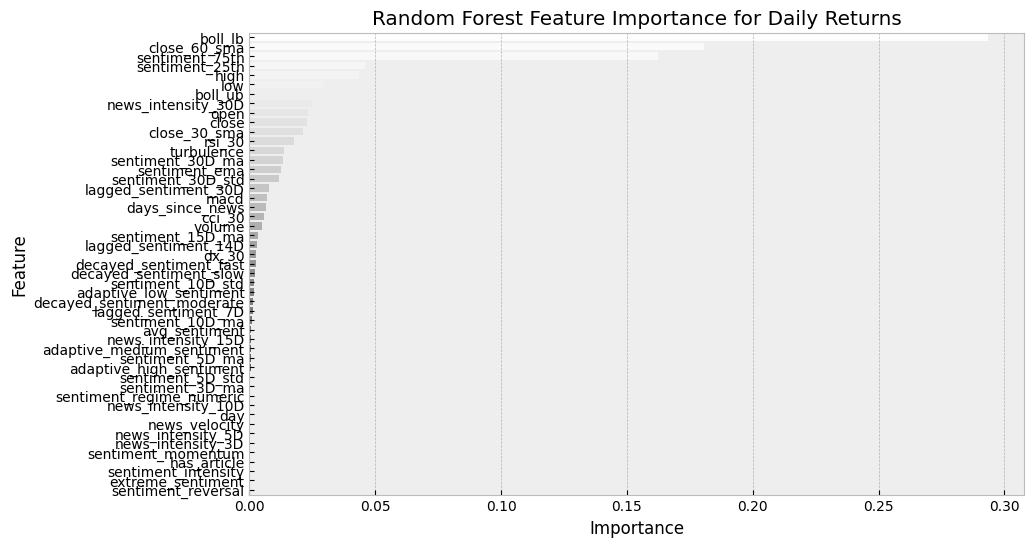

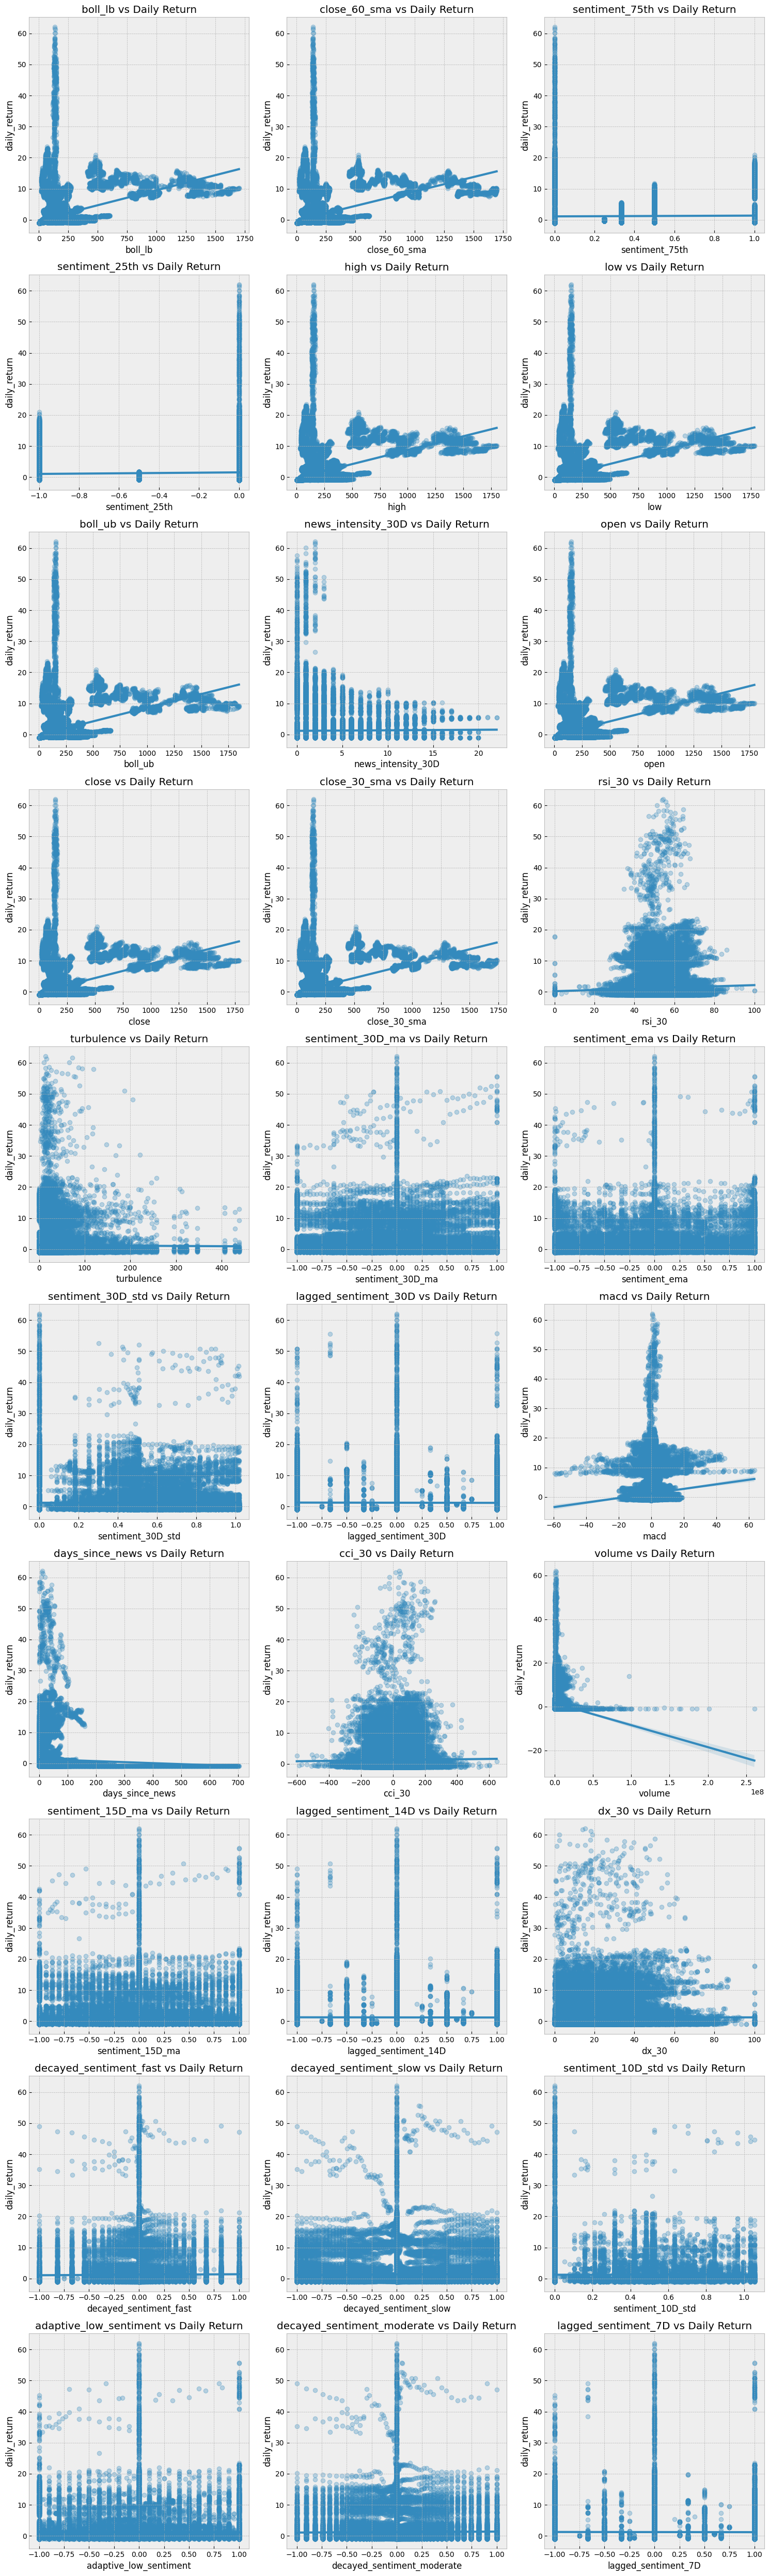

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

processed['daily_return'] = processed['close'].pct_change()# Calculate daily returns
processed = processed.fillna(processed['daily_return'].mean())# Fill first row with avergae as it will have NaN due to pct_change()


# Select sentiment features and target
features = [
    'open', 'high', 'low', 'close', 'volume', 'day',
    'has_article', 'avg_sentiment', 'days_since_news',
    'decayed_sentiment_slow', 'decayed_sentiment_moderate', 'decayed_sentiment_fast',
    'sentiment_momentum',
    'sentiment_3D_ma', 'sentiment_5D_ma', 'sentiment_10D_ma', 'sentiment_15D_ma', 'sentiment_30D_ma',
    'news_intensity_3D', 'news_intensity_5D', 'news_intensity_10D', 'news_intensity_15D', 'news_intensity_30D',
    'news_velocity',
    'sentiment_regime_numeric',
    'sentiment_reversal',
    'extreme_sentiment',
    'adaptive_high_sentiment', 'adaptive_medium_sentiment', 'adaptive_low_sentiment',
    'sentiment_25th', 'sentiment_75th',
    'lagged_sentiment_7D', 'lagged_sentiment_14D', 'lagged_sentiment_30D',
    'sentiment_intensity',
    'sentiment_ema',
    'sentiment_5D_std', 'sentiment_10D_std', 'sentiment_30D_std',
    'macd', 'boll_ub', 'boll_lb','rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma',
    'turbulence',
]
target = 'daily_return'

# Core validation
assert processed['avg_sentiment'].between(-1, 1).all(), "Bad sentiment values"
assert processed['sentiment_momentum'].between(-2, 2).all(), "Bad momentum values"

# Feature stats
stats = {
    'News': f"{processed['has_article'].mean():.1%} days",
    'Max gap': f"{processed['days_since_news'].max()} days",
    '5D MA': f"{processed['sentiment_5D_ma'].min():.1f} to {processed['sentiment_5D_ma'].max():.1f}",
    '5D news': f"{processed['news_intensity_5D'].min()} to {processed['news_intensity_5D'].max()} articles"
}
print(" | ".join(f"{k}: {v}" for k, v in stats.items()))

print("Correlation Matrix:")
corr_matrix = processed[[target]+features].corr()
display(corr_matrix.sort_values(by=target, ascending=False))
corr_matrix.to_csv('corr_matrix.csv', index=False) #Save to csv

# Feature importance with Random Forest
X = processed[features].fillna(0)
y = processed[target]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("\nRandom Forest Feature Importance:")
display(feature_importance)
feature_importance.to_csv('feature_importance.csv', index=False) #Save to csv

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette="Greys")
plt.title('Random Forest Feature Importance for Daily Returns')
plt.show()

# Additional visualization: Scatter plots for top features as subplots
top_features = feature_importance['Feature'].head(30)

# Create subplots with a grid to display multiple scatter plots
n_features = len(top_features)
n_cols = 3  # Set the number of columns in the subplot grid
n_rows = (n_features + n_cols - 1) // n_cols  # Calculate the number of rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

# Flatten the axes array to easily iterate
axes = axes.flatten()

# Loop through the top features and create a scatter plot on each subplot
for i, feature in enumerate(top_features):
    sns.regplot(x=processed[feature], y=processed[target], scatter_kws={'alpha': 0.3}, ax=axes[i])
    axes[i].set_title(f'{feature} vs Daily Return')

# Remove any empty subplots
for i in range(n_features, len(axes)):
    fig.delaxes(axes[i])

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [ ]:
# Define the feature sets
TOP_15_FEATURES = ['boll_lb', 'close_60_sma', 'sentiment_75th', 'sentiment_25th',
                   'high', 'low', 'boll_ub', 'news_intensity_30D', 'open', 'close',
                   'close_30_sma', 'rsi_30', 'turbulence', 'sentiment_ema', 'sentiment_30D_ma']

TOP_TECH_FEATURES = ['boll_lb', 'close_60_sma','high', 'low', 'open', 'close',
                     'boll_ub', 'rsi_30', 'turbulence', 'macd', 'volume']

TOP_SENT_FEATURES = ['sentiment_75th', 'sentiment_25th',
                     'high', 'low', 'news_intensity_30D', 'open', 'close',
                     'turbulence', 'sentiment_ema', 'sentiment_30D_ma']


# Filter df based on feature sets
processed_top_15 = processed[['date', 'tic'] + TOP_15_FEATURES].fillna(0)
processed_top_tech = processed[['date', 'tic'] + TOP_TECH_FEATURES].fillna(0)
processed_top_sent = processed[['date', 'tic'] + TOP_SENT_FEATURES].fillna(0)

# Save preprocessed data (debugging)
processed_top_15.to_csv('processed_top_15.csv', index=False)
processed_top_tech.to_csv('processed_top_tech.csv', index=False)
processed_top_sent.to_csv('processed_top_sent.csv', index=False)

## Part 4. Design Environment
A custom Gym environment is constructed to simulate trading on OMXS30 stocks, with the following configuration:

- **Observation Space**: Concatenated technical and sentiment features + portfolio state
- **Action Space**: Discrete (buy, sell, hold) for each asset
- **Reward**: Portfolio return per step, net of transaction cost (0.1%)

Portfolio constraints:
- Max holding per asset = 10% of NAV
- Cash buffer = 5% minimum
- Daily rebalancing; partial trades allowed

The agent observes a multivariate state and must learn optimal trade allocations under uncertainty.

In [ ]:
processed_top_15.sample(5)

,date,tic,boll_lb,close_60_sma,sentiment_75th,sentiment_25th,high,low,boll_ub,news_intensity_30D,open,close,close_30_sma,rsi_30,turbulence,sentiment_ema,sentiment_30D_ma
52161,2022-09-07,TEL2-B.ST,93.713039,97.237688,0.0,-0.5,113.400002,111.800003,99.102993,0.0,113.000000,94.183655,96.386311,43.634919,13.541882,-0.999996,-1.000000
1173,2015-03-06,INVE-B.ST,58.576930,59.201151,1.0,0.0,83.000000,81.824997,66.475849,1.0,82.574997,64.052895,61.296508,67.951025,0.000000,0.000000,0.000000
2301,2015-05-08,BOL.ST,117.326381,117.350350,1.0,-1.0,178.899994,173.199997,136.689434,2.0,178.500000,122.088402,123.983889,54.432029,0.000000,-0.997970,-0.133333
59081,2023-09-13,AZN.ST,1473.900797,1476.391496,1.0,-1.0,1497.000000,1480.500000,1518.098849,4.0,1489.500000,1482.012451,1497.054716,48.866398,10.385832,-0.813730,-0.433333
185,2015-01-14,SWED-A.ST,88.408134,91.829606,0.0,-1.0,185.800003,181.800003,95.251078,2.0,185.699997,89.694031,91.829606,14.058793,0.000000,0.469136,0.428571


In [ ]:
selected_features_df=processed_top_15 # specify which feature set to use

# Dynamically get engineered features
ENGINEERED_FEATURES = selected_features_df[selected_features_df.columns.difference(['open', 'high', 'low', 'close','volume','turbulence', 'date', 'tic', 'daily_return', 'day'])].columns.tolist()
print(f"Engineered Features: {ENGINEERED_FEATURES}")

stock_dimension = len(selected_features_df.tic.unique())
state_space = (
    1  # turbulence
    + 2 * stock_dimension  # price data
    + len(ENGINEERED_FEATURES) * stock_dimension
)
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

env_kwargs = {
    "hmax": 100,
    "initial_amount": 1000000,
    "buy_cost_pct": 0.001,
    "sell_cost_pct": 0.001,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": ENGINEERED_FEATURES,
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
    "print_verbosity":5
}

Engineered Features: ['boll_lb', 'boll_ub', 'close_30_sma', 'close_60_sma', 'news_intensity_30D', 'rsi_30', 'sentiment_25th', 'sentiment_30D_ma', 'sentiment_75th', 'sentiment_ema']
Stock Dimension: 27, State Space: 325


## Part 5. DRL Algorithm Configuration and Model Training
We train multiple DRL agents using the `FinRL` and `ElegantRL` libraries:

- **Baseline Models**: DDPG, PPO, SAC, A2C and TD3
- **Ensemble Agent**: Uses performance-weighted voting across trained base agents
- **Sentiment-Augmented Variants**: Each agent is trained both with and without sentiment features

Training Parameters:
- Episodes: 500
- Learning Rate: 1e-4
- Gamma (discount factor): 0.99
- Batch size: 2048
- Early stopping: based on Sharpe ratio plateau

* In this notebook, we are training and validating 5 agents using Rolling-window Ensemble Method ([reference code](https://github.com/AI4Finance-Foundation/FinRL/blob/master/finrl/agents/stablebaselines3/models.py))

In [ ]:
rebalance_window = 63 # rebalance_window is the number of days to retrain the model
validation_window = 63 # validation_window is the number of days to do validation and trading (e.g. if validation_window=63, then both validation and trading period will be 63 days)

ensemble_agent = DRLEnsembleAgent(df=selected_features_df,
                 train_period=(TRAIN_START_DATE,TRAIN_END_DATE), #Ensure date ranges are set
                 val_test_period=(TEST_START_DATE,TEST_END_DATE),
                 rebalance_window=rebalance_window,
                 validation_window=validation_window,
                 **env_kwargs)



In [ ]:
A2C_model_kwargs = {'n_steps': 5, 'ent_coef': 0.005, 'learning_rate': 0.0007}

PPO_model_kwargs = {"ent_coef":0.01, "n_steps": 2048, "learning_rate": 0.00025, "batch_size": 128}

DDPG_model_kwargs = {#"action_noise":"ornstein_uhlenbeck",
                     "buffer_size": 10_000,
                      "learning_rate": 0.0005,
                      "batch_size": 64}

SAC_model_kwargs = {"batch_size": 64, "buffer_size": 100000, "learning_rate": 0.0001, "learning_starts": 100,"ent_coef": "auto_0.1",}

TD3_model_kwargs = {"batch_size": 100, "buffer_size": 1000000, "learning_rate": 0.0001}

timesteps_dict = {'a2c' : 10_000, 'ppo' : 10_000, 'ddpg' : 10_000, 'sac' : 10_000, 'td3' : 10_000}

df_summary = ensemble_agent.run_ensemble_strategy(A2C_model_kwargs,
                                                 PPO_model_kwargs,
                                                 DDPG_model_kwargs,
                                                 SAC_model_kwargs,
                                                 TD3_model_kwargs,
                                                 timesteps_dict)

============Start Ensemble Strategy============
turbulence_threshold:  196.70360729569558
======Model training from:  2015-01-05 to  2023-07-28 00:00:00
======a2c Training========
{'n_steps': 5, 'ent_coef': 0.005, 'learning_rate': 0.0007}
Using cpu device
Logging to tensorboard_log/a2c/a2c_126_2
--------------------------------------
| time/                 |            |
|    fps                | 76         |
|    iterations         | 100        |
|    time_elapsed       | 6          |
|    total_timesteps    | 500        |
| train/                |            |
|    entropy_loss       | -38.1      |
|    explained_variance | -0.509     |
|    learning_rate      | 0.0007     |
|    n_updates          | 99         |
|    policy_loss        | -17.4      |
|    reward             | -0.6531123 |
|    std                | 0.994      |
|    value_loss         | 0.411      |
--------------------------------------
---------------------------------------
| time/                 |             |

In [ ]:
df_summary #top 15 features

,Iter,Val Start,Val End,Model Used,A2C Sharpe,PPO Sharpe,DDPG Sharpe,SAC Sharpe,TD3 Sharpe
0,126,2023-07-28 00:00:00,2023-10-25 00:00:00,SAC,-0.358776,-0.299764,-0.319005,-0.226371,-0.273508
1,189,2023-10-25 00:00:00,2024-01-25 00:00:00,A2C,0.486862,0.350443,0.19003,0.418394,0.264193
2,252,2024-01-25 00:00:00,2024-04-25 00:00:00,A2C,0.683729,0.400831,0.477136,0.474039,0.322102
3,315,2024-04-25 00:00:00,2024-07-29 00:00:00,DDPG,0.109887,-0.110289,0.170686,0.014643,0.108381


In [ ]:
df_summary # top_tech_features

,Iter,Val Start,Val End,Model Used,A2C Sharpe,PPO Sharpe,DDPG Sharpe,SAC Sharpe,TD3 Sharpe
0,126,2023-07-28 00:00:00,2023-10-25 00:00:00,SAC,-0.261706,-0.344557,-0.258384,-0.206721,-0.31994
1,189,2023-10-25 00:00:00,2024-01-25 00:00:00,TD3,0.359944,0.074089,0.500811,0.308039,0.512659
2,252,2024-01-25 00:00:00,2024-04-25 00:00:00,DDPG,0.269701,0.18843,0.567353,0.380316,0.431206
3,315,2024-04-25 00:00:00,2024-07-29 00:00:00,DDPG,-0.034544,-0.086158,0.11759,-0.122311,0.041166


In [ ]:
df_summary # top_sent_features

,Iter,Val Start,Val End,Model Used,A2C Sharpe,PPO Sharpe,DDPG Sharpe,SAC Sharpe,TD3 Sharpe
0,126,2023-07-28 00:00:00,2023-10-25 00:00:00,PPO,-0.262187,-0.249433,-0.303201,-0.296742,-0.292122
1,189,2023-10-25 00:00:00,2024-01-25 00:00:00,DDPG,0.181039,0.266077,0.476578,0.382977,0.356579
2,252,2024-01-25 00:00:00,2024-04-25 00:00:00,PPO,0.6202,0.698195,0.582029,0.614206,0.56921
3,315,2024-04-25 00:00:00,2024-07-29 00:00:00,DDPG,0.072394,0.077679,0.086997,0.044275,0.072584


In [ ]:
df_summary # top 15 features

## Part 6. Backtesting and Evaluation
Backtesting plays a key role in evaluating the performance of a trading strategy. Automated backtesting tool is preferred because it reduces the human error. We usually use the Quantopian pyfolio package to backtest our trading strategies. It is easy to use and consists of various individual plots that provide a comprehensive image of the performance of a trading strategy.

In [ ]:
unique_trade_date = selected_features_df[(selected_features_df.date > TEST_START_DATE)&(selected_features_df.date <= TEST_END_DATE)].date.unique()

In [ ]:
df_trade_date = pd.DataFrame({'datadate': unique_trade_date})

df_account_value = pd.DataFrame()
for i in range(rebalance_window + validation_window, len(unique_trade_date) + 1, rebalance_window):
    temp = pd.read_csv(f'results/account_value_trade_ensemble_{i}.csv')
    df_account_value = pd.concat([df_account_value, temp], ignore_index=True)

sharpe = (252**0.5) * df_account_value['account_value'].pct_change(1).mean() / df_account_value['account_value'].pct_change(1).std()
print('Sharpe Ratio: ', sharpe)

df_account_value = df_account_value.join(df_trade_date.iloc[validation_window:].reset_index(drop=True))


Sharpe Ratio:  0.6593794247153315


In [ ]:
df_account_value.head()

,account_value,date,daily_return,datadate
0,1000000.000000,2023-10-25,NaN,2023-10-25
1,999306.815105,2023-10-26,-0.000693,2023-10-26
2,989855.057139,2023-10-27,-0.009458,2023-10-27
3,991757.076020,2023-10-30,0.001922,2023-10-30
4,992032.557192,2023-10-31,0.000278,2023-10-31


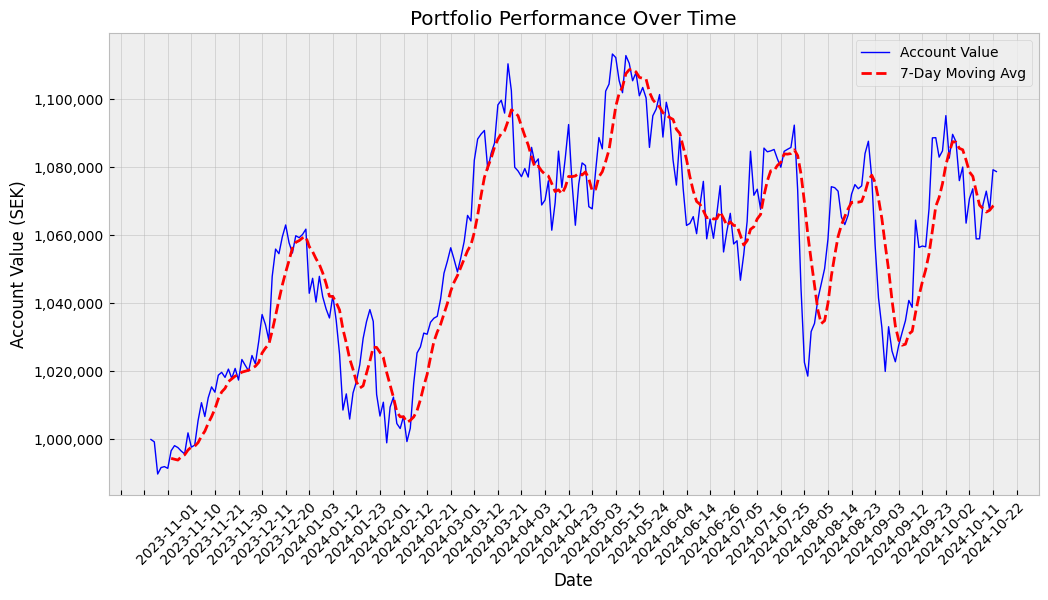

In [ ]:
import matplotlib.pyplot as plt, matplotlib.dates as mdates, matplotlib.ticker as ticker
%matplotlib inline
plt.style.use("bmh")
df_account_value["SMA_7"] = df_account_value["account_value"].rolling(7).mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_account_value["date"], df_account_value["account_value"], label="Account Value", color="b", linewidth=1)
ax.plot(df_account_value["date"], df_account_value["SMA_7"], label="7-Day Moving Avg", color="r", linestyle="--")

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set(xlabel="Date", ylabel="Account Value (SEK)", title="Portfolio Performance Over Time")
ax.xaxis.set_major_locator(mdates.WeekdayLocator())
ax.legend()
plt.xticks(rotation=45)
ax.grid(True, linestyle="-", alpha=0.6)
plt.show()

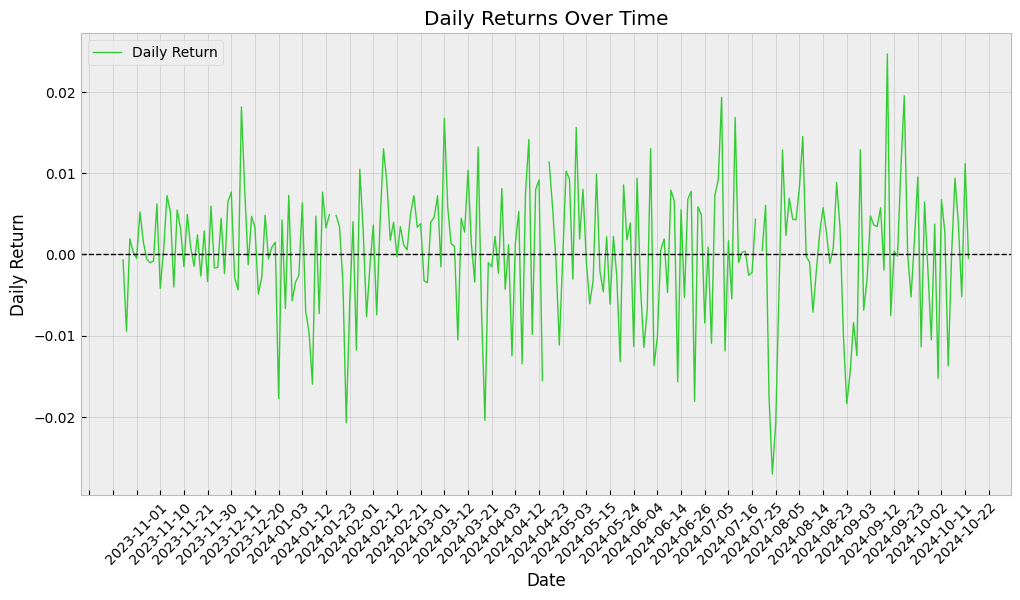

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set style
plt.style.use("bmh")

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot daily returns
ax.plot(df_account_value["date"], df_account_value["daily_return"], label="Daily Return", color="limegreen", linestyle="-", linewidth=1)

# Format the x-axis for better readability
ax.xaxis.set_major_locator(mdates.WeekdayLocator())  # Major ticks per month
plt.xticks(rotation=45)  # Rotate labels

# Add a horizontal line at 0 for reference
ax.axhline(y=0, color="black", linestyle="--", linewidth=1)

# Labels and title
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return")
ax.set_title("Daily Returns Over Time")
ax.legend()

# Show grid and plot
ax.grid(True, linestyle="-", alpha=0.6)
plt.show()


### 6.1 BackTestStats
pass in df_account_value, this information is stored in env class


In [ ]:
print("==============Get Backtest Results===========")
now = datetime.datetime.now().strftime('%Y%m%d-%Hh%M')

perf_stats_all = backtest_stats(account_value=df_account_value)
perf_stats_all = pd.DataFrame(perf_stats_all)

==============Get Backtest Results===========
Annual return          0.078709
Cumulative returns     0.078709
Annual volatility      0.127721
Sharpe ratio           0.659379
Calmar ratio           0.926071
Stability              0.314295
Max drawdown          -0.084993
Omega ratio            1.113928
Sortino ratio          0.908111
Skew                        NaN
Kurtosis                    NaN
Tail ratio             0.910974
Daily value at risk   -0.015757
dtype: float64


In [ ]:
print("==============Get Baseline Stats===========")
df_omx_ = get_baseline(
        ticker="^OMX",
        start = df_account_value.loc[0,'date'],
        end = df_account_value.loc[len(df_account_value)-1,'date'])

stats = backtest_stats(df_omx_, value_col_name = 'close')

[*********************100%***********************]  1 of 1 completed

==============Get Baseline Stats===========
Shape of DataFrame:  (251, 8)
Annual return          0.241038
Cumulative returns     0.239975
Annual volatility      0.124023
Sharpe ratio           1.810731
Calmar ratio           2.669468
Stability              0.674326
Max drawdown          -0.090294
Omega ratio            1.336938
Sortino ratio          2.695569
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.096919
Daily value at risk   -0.014734
dtype: float64


In [ ]:
df_omx = pd.DataFrame()
df_omx['date'] = df_account_value['date']
df_omx['omx'] = df_omx_['close'] / df_omx_['close'][0] * env_kwargs["initial_amount"]
display("df_omx: ", df_omx)
df_omx.to_csv("df_omx.csv")
df_omx = df_omx.set_index(df_omx.columns[0])
display("df_omx: ", df_omx)
df_omx.to_csv("df_omx+.csv")

df_account_value.to_csv('account_value_top.csv') # top, technical or sentiment

'df_omx: '

,date,omx
0,2023-10-25,1.000000e+06
1,2023-10-26,9.955204e+05
2,2023-10-27,9.883356e+05
3,2023-10-30,9.919472e+05
4,2023-10-31,1.000940e+06
...,...,...
247,2024-10-17,1.246871e+06
248,2024-10-18,1.250964e+06
249,2024-10-21,1.242237e+06
250,2024-10-22,1.239975e+06


'df_omx: '

,omx
date,
2023-10-25,1.000000e+06
2023-10-26,9.955204e+05
2023-10-27,9.883356e+05
2023-10-30,9.919472e+05
2023-10-31,1.000940e+06
...,...
2024-10-17,1.246871e+06
2024-10-18,1.250964e+06
2024-10-21,1.242237e+06


### 6.2 BackTestPlot

             account_value           omx
date                                    
2023-10-25  1000000.000000  1.000000e+06
2023-10-26   999306.815105  9.955204e+05
2023-10-27   989855.057139  9.883356e+05
2023-10-30   991757.076020  9.919472e+05
2023-10-31   992032.557192  1.000940e+06
==============Compare to OMX===========


<Figure size 1200x600 with 0 Axes>

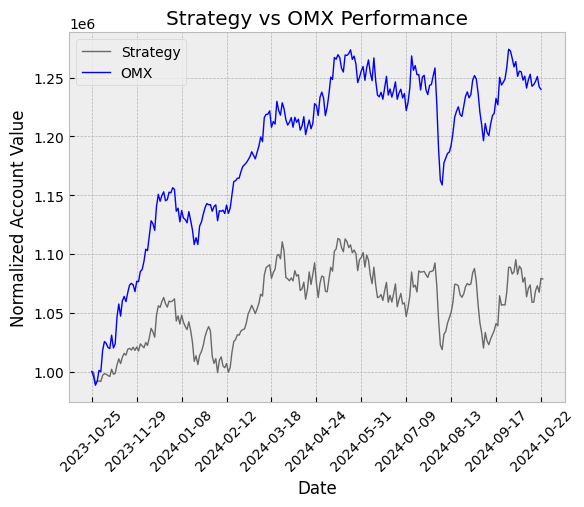

In [ ]:
df_account_value.set_index('date', inplace=True)

# Merge strategy results with baseline data
result = pd.merge(df_account_value[['account_value']], df_omx[['omx']], left_index=True, right_index=True)
print(result.head())

# Plot strategy vs OMX
print("==============Compare to OMX===========")
plt.figure(figsize=(12, 6))
result.plot(title="Strategy vs OMX Performance", xlabel="Date", ylabel="Normalized Account Value",
            xticks=range(0, len(result), len(result)//10),
            color=["dimgrey", "blue"], linewidth=1)
# Set consistent y-axis span
# ax.set_ylim([90000, 140000])
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))  # Apply comma formatting for large numbers
plt.xticks(rotation=45)  # Rotate date labels for readability
plt.legend(["Strategy", "OMX"])
plt.show()